In [393]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

In [394]:
NUMBER_OF_FLOWS = 50

STEPS = 5
INTERVAL_LENGTH = int(NUMBER_OF_FLOWS / STEPS)

scaler = MinMaxScaler(feature_range=(0, 130))

In [395]:
def acceptance_rate(ar_array, time_array) -> List:
    splitted_ar_array = []
    base_time = 0
    split = []
    for time, ar in zip(time_array, ar_array):
        split.append(ar)
        # if end of interval, Calculate another split
        if time >= base_time + 10:
            base_time = time
            splitted_ar_array.append(split)
            split = []
    acc_rate_array = []
    for split in splitted_ar_array:
        arr_data, counts = np.unique(split, return_counts=True)
        if len(counts) == 1:
            if arr_data[0] == 0:
                acc_rate = 0
            elif arr_data[0] == 1:
                acc_rate = 1
        else:
            try:
                count_succ = counts[1]
                count_fail = counts[0]
                acc_rate = count_succ / (count_succ + count_fail)
            except:
                return []
        acc_rate_array.append(acc_rate)
    return acc_rate_array

In [396]:
def acceptance_rate_cumulative(ar_array) -> List:
    step = round(len(ar_array) / INTERVAL_LENGTH)
    acc_rate_array = []
    end = step
    while True:
        if end > len(ar_array):
            break
        window = ar_array[0:end]
        arr_data, counts = np.unique(window, return_counts=True)
        if len(counts) == 1:
            if arr_data[0] == 0:
                acc_rate = 0
            elif arr_data[0] == 1:
                acc_rate = 1
        else:
            try:
                count_succ = counts[1]
                count_fail = counts[0]
                acc_rate = count_succ / (count_succ + count_fail)
            except:
                return []
        acc_rate_array.append(acc_rate)
        end = end + step
    return acc_rate_array

In [397]:
def resource_utilization_cumulative(ar_array) -> List:
    step = round(len(ar_array) / INTERVAL_LENGTH)
    end = step
    resource_utilization = []
    while True:
        if end > len(ar_array):
            break
        window = ar_array[0:end]
        if len(window) == 0:
            continue
        average_consumption = np.mean(window)
        resource_utilization.append(average_consumption)
        end = end + step
    return resource_utilization

In [398]:
def resource_utilization(ar_array, time_array) -> List:
    resource_utilization = []
    splitted_ar_array = []
    base_time = 0
    split = []
    for time, ar in zip(time_array, ar_array):
        split.append(ar)
        # if end of interval, Calculate another split
        if time >= base_time + 10:
            base_time = time
            splitted_ar_array.append(split)
            split = []
    for split in splitted_ar_array:
        if len(split) == 0:
            continue
        average_consumption = np.mean(split)
        resource_utilization.append(average_consumption)
    return resource_utilization

In [399]:
results_flows_directories = glob.glob("../results_flows_*")

In [400]:
from fnmatch import fnmatch

df = pd.DataFrame()
df_resource = pd.DataFrame()
for result_flows in results_flows_directories:
    results_algorithms = os.listdir(result_flows)
    for result_algorithms in results_algorithms:
        if fnmatch(result_algorithms, "*_sfc_off_*"):
            sfc_type = "off"
        else:
            sfc_type = "on"
        path_algorithms = str(result_flows) + "/" + result_algorithms
        for i, file in enumerate(os.listdir(path_algorithms)):
            try:
                df_file = pd.read_csv(path_algorithms + "/" + file)
                df_file["prob"] = str(result_algorithms).split("_")[5]
                df_file["algorithm"] = str(result_algorithms).split("_")[0]
                df_file["n_execution"] = i
                df_file["sfc"] = sfc_type
                df_resource = pd.concat([df, df_file], ignore_index=True)
                # df_file = df_file.drop_duplicates(subset=['sfc_id'], keep='last')
                df = pd.concat([df, df_file], ignore_index=True)
            except:
                continue

In [401]:
def count_unique(ar):
    memo = []
    for item in ar:
        if item not in memo:
            memo.append(item)
    return len(memo)

In [402]:
df = df[
    df.groupby(["sfc", "algorithm", "prob", "n_execution"])["sfc_id"]
    .transform(count_unique)
    .isin([NUMBER_OF_FLOWS * 4, NUMBER_OF_FLOWS * 4 * 2])
]

In [403]:
df_resource = df_resource[df_resource["latency"] != "latency"]
df = df[df["latency"] != "latency"]

In [404]:
df.loc[:, "latency"] = df.loc[:, "latency"].replace("None", -1)
df_resource.loc[:, "latency"] = df_resource.loc[:, "latency"].replace("None", -1)

In [405]:
df.loc[:, "latency"] = df.loc[:, "latency"].astype(float)
df_resource.loc[:, "latency"] = df_resource.loc[:, "latency"].astype(float)

In [406]:
data_plot = {}
for group in df.groupby(["sfc", "algorithm", "prob", "n_execution"]):
    key_dict = group[0][:-1]
    if key_dict in data_plot.keys():
        time_array = scaler.fit_transform(group[1]["timestamp"].values.reshape(-1, 1))
        data_plot[key_dict].append(acceptance_rate(group[1]["success"].values, time_array))
    else:
        data_plot[key_dict] = []

In [407]:
arr_dp_on_0 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "dp", "0.0")]))
)
arr_dp_on_10 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "dp", "0.1")]))
)
arr_dp_on_20 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "dp", "0.2")]))
)
arr_dp_on_30 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "dp", "0.3")]))
)
arr_dp_on_40 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "dp", "0.4")]))
)
arr_dp_on_50 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "dp", "0.5")]))
)

"""
arr_dp_o_60 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'dp', '0.6')])))
arr_dp_on_70 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'dp', '0.7')])))
arr_dp_on_80 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'dp', '0.8')])))
arr_dp_on_90 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'dp', '0.9')])))
arr_dp_on_100 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'dp', '1.0')])))
"""

arr_dpnew_on_0 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "musfico", "0.0")]))
)
arr_dpnew_on_10 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "musfico", "0.1")]))
)
arr_dpnew_on_20 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "musfico", "0.2")]))
)
arr_dpnew_on_30 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "musfico", "0.3")]))
)
arr_dpnew_on_40 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "musfico", "0.4")]))
)
arr_dpnew_on_50 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "musfico", "0.5")]))
)

"""
arr_dpnew_on_60 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'musfico', '0.6')])))
arr_dpnew_on_70 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'musfico', '0.7')])))
arr_dpnew_on_80 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'musfico', '0.8')])))
arr_dpnew_on_90 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'musfico', '0.9')])))
arr_dpnew_on_100 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'musfico', '1.0')])))
"""

arr_dpnew_off_0 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("off", "musfico", "0.0")]))
)
arr_dpnew_off_10 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("off", "musfico", "0.1")]))
)
arr_dpnew_off_20 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("off", "musfico", "0.2")]))
)
arr_dpnew_off_30 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("off", "musfico", "0.3")]))
)
arr_dpnew_off_40 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("off", "musfico", "0.4")]))
)
arr_dpnew_off_50 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("off", "musfico", "0.5")]))
)
"""
arr_dpnew_off_60 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('off', 'musfico', '0.6')])))
arr_dpnew_off_70 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('off', 'musfico', '0.7')])))
arr_dpnew_off_80 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('off', 'musfico', '0.8')])))
arr_dpnew_off_90 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('off', 'musfico', '0.9')])))
arr_dpnew_off_100 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('off', 'musfico', '1.0')])))
"""

arr_g_on_0 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "g", "0.0")]))
)
arr_g_on_10 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "g", "0.1")]))
)
arr_g_on_20 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "g", "0.2")]))
)
arr_g_on_30 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "g", "0.3")]))
)
arr_g_on_40 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "g", "0.4")]))
)
arr_g_on_50 = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[("on", "g", "0.5")]))
)
"""
arr_g_on_60 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '0.6')])))
arr_g_on_70 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '0.7')])))
arr_g_on_80 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '0.8')])))
arr_g_on_90 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '0.9')])))
arr_g_on_100 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '1.0')])))
"""

"\narr_g_on_60 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '0.6')])))\narr_g_on_70 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '0.7')])))\narr_g_on_80 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '0.8')])))\narr_g_on_90 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '0.9')])))\narr_g_on_100 = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot[('on', 'g', '1.0')])))\n"

In [408]:
arr_dp_on_0 = np.vstack(arr_dp_on_0)
arr_dp_on_10 = np.vstack(arr_dp_on_10)
arr_dp_on_20 = np.vstack(arr_dp_on_20)
arr_dp_on_30 = np.vstack(arr_dp_on_30)
arr_dp_on_40 = np.vstack(arr_dp_on_40)
arr_dp_on_50 = np.vstack(arr_dp_on_50)

"""
arr_dp_on_60 = np.vstack(arr_dp_on_60)
arr_dp_on_70 = np.vstack(arr_dp_on_70)
arr_dp_on_80 = np.vstack(arr_dp_on_80)
arr_dp_on_90 = np.vstack(arr_dp_on_90)
arr_dp_on_100 = np.vstack(arr_dp_on_100)
"""

arr_dpnew_on_0 = np.vstack(arr_dpnew_on_0)
arr_dpnew_on_10 = np.vstack(arr_dpnew_on_10)
arr_dpnew_on_20 = np.vstack(arr_dpnew_on_20)
arr_dpnew_on_30 = np.vstack(arr_dpnew_on_30)
arr_dpnew_on_40 = np.vstack(arr_dpnew_on_40)
arr_dpnew_on_50 = np.vstack(arr_dpnew_on_50)

"""
arr_dpnew_on_60 = np.vstack(arr_dpnew_on_60)
arr_dpnew_on_70 = np.vstack(arr_dpnew_on_70)
arr_dpnew_on_80 = np.vstack(arr_dpnew_on_80)
arr_dpnew_on_90 = np.vstack(arr_dpnew_on_90)
arr_dpnew_on_100 = np.vstack(arr_dpnew_on_100)
"""

arr_dpnew_off_0 = np.vstack(arr_dpnew_off_0)
arr_dpnew_off_10 = np.vstack(arr_dpnew_off_10)
arr_dpnew_off_20 = np.vstack(arr_dpnew_off_20)
arr_dpnew_off_30 = np.vstack(arr_dpnew_off_30)
arr_dpnew_off_40 = np.vstack(arr_dpnew_off_40)
arr_dpnew_off_50 = np.vstack(arr_dpnew_off_50)

"""
arr_dpnew_off_60 = np.vstack(arr_dpnew_off_60)
arr_dpnew_off_70 = np.vstack(arr_dpnew_off_70)
arr_dpnew_off_80 = np.vstack(arr_dpnew_off_80)
arr_dpnew_off_90 = np.vstack(arr_dpnew_off_90)
arr_dpnew_off_100 = np.vstack(arr_dpnew_off_100)
"""

arr_g_on_0 = np.vstack(arr_g_on_0)
arr_g_on_10 = np.vstack(arr_g_on_10)
arr_g_on_20 = np.vstack(arr_g_on_20)
arr_g_on_30 = np.vstack(arr_g_on_30)
arr_g_on_40 = np.vstack(arr_g_on_40)
arr_g_on_50 = np.vstack(arr_g_on_50)

"""
arr_g_on_60 = np.vstack(arr_g_on_60)
arr_g_on_70 = np.vstack(arr_g_on_70)
arr_g_on_80 = np.vstack(arr_g_on_80)
arr_g_on_90 = np.vstack(arr_g_on_90)
arr_g_on_100 = np.vstack(arr_g_on_100)
"""

'\narr_g_on_60 = np.vstack(arr_g_on_60)\narr_g_on_70 = np.vstack(arr_g_on_70)\narr_g_on_80 = np.vstack(arr_g_on_80)\narr_g_on_90 = np.vstack(arr_g_on_90)\narr_g_on_100 = np.vstack(arr_g_on_100)\n'

In [409]:
mean_arr_dp_on_0 = np.mean(arr_dp_on_0, axis=0)
mean_arr_dp_on_10 = np.mean(arr_dp_on_10, axis=0)
mean_arr_dp_on_20 = np.mean(arr_dp_on_20, axis=0)
mean_arr_dp_on_30 = np.mean(arr_dp_on_30, axis=0)
mean_arr_dp_on_40 = np.mean(arr_dp_on_40, axis=0)
mean_arr_dp_on_50 = np.mean(arr_dp_on_50, axis=0)

"""
mean_arr_dp_on_60 = np.mean(arr_dp_on_60, axis=0)
mean_arr_dp_on_70 = np.mean(arr_dp_on_70, axis=0)
mean_arr_dp_on_80 = np.mean(arr_dp_on_80, axis=0)
mean_arr_dp_on_90 = np.mean(arr_dp_on_90, axis=0)
mean_arr_dp_on_100 = np.mean(arr_dp_on_100, axis=0)
"""

mean_arr_dpnew_on_0 = np.mean(arr_dpnew_on_0, axis=0)
mean_arr_dpnew_on_10 = np.mean(arr_dpnew_on_10, axis=0)
mean_arr_dpnew_on_20 = np.mean(arr_dpnew_on_20, axis=0)
mean_arr_dpnew_on_30 = np.mean(arr_dpnew_on_30, axis=0)
mean_arr_dpnew_on_40 = np.mean(arr_dpnew_on_40, axis=0)
mean_arr_dpnew_on_50 = np.mean(arr_dpnew_on_50, axis=0)

"""
mean_arr_dpnew_on_60 = np.mean(arr_dpnew_on_60, axis=0)
mean_arr_dpnew_on_70 = np.mean(arr_dpnew_on_70, axis=0)
mean_arr_dpnew_on_80 = np.mean(arr_dpnew_on_80, axis=0)
mean_arr_dpnew_on_90 = np.mean(arr_dpnew_on_90, axis=0)
mean_arr_dpnew_on_100 = np.mean(arr_dpnew_on_100, axis=0)
"""

mean_arr_dpnew_off_0 = np.mean(arr_dpnew_off_0, axis=0)
mean_arr_dpnew_off_10 = np.mean(arr_dpnew_off_10, axis=0)
mean_arr_dpnew_off_20 = np.mean(arr_dpnew_off_20, axis=0)
mean_arr_dpnew_off_30 = np.mean(arr_dpnew_off_30, axis=0)
mean_arr_dpnew_off_40 = np.mean(arr_dpnew_off_40, axis=0)
mean_arr_dpnew_off_50 = np.mean(arr_dpnew_off_50, axis=0)

"""
mean_arr_dpnew_off_60 = np.mean(arr_dpnew_off_60, axis=0)
mean_arr_dpnew_off_70 = np.mean(arr_dpnew_off_70, axis=0)
mean_arr_dpnew_off_80 = np.mean(arr_dpnew_off_80, axis=0)
mean_arr_dpnew_off_90 = np.mean(arr_dpnew_off_90, axis=0)
mean_arr_dpnew_off_100 = np.mean(arr_dpnew_off_100, axis=0)
"""

mean_arr_g_on_0 = np.mean(arr_g_on_0, axis=0)
mean_arr_g_on_10 = np.mean(arr_g_on_10, axis=0)
mean_arr_g_on_20 = np.mean(arr_g_on_20, axis=0)
mean_arr_g_on_30 = np.mean(arr_g_on_30, axis=0)
mean_arr_g_on_40 = np.mean(arr_g_on_40, axis=0)
mean_arr_g_on_50 = np.mean(arr_g_on_50, axis=0)

"""
mean_arr_g_on_60 = np.mean(arr_g_on_60, axis=0)
mean_arr_g_on_70 = np.mean(arr_g_on_70, axis=0)
mean_arr_g_on_80 = np.mean(arr_g_on_80, axis=0)
mean_arr_g_on_90 = np.mean(arr_g_on_90, axis=0)
mean_arr_g_on_100 = np.mean(arr_g_on_100, axis=0)
"""

'\nmean_arr_g_on_60 = np.mean(arr_g_on_60, axis=0)\nmean_arr_g_on_70 = np.mean(arr_g_on_70, axis=0)\nmean_arr_g_on_80 = np.mean(arr_g_on_80, axis=0)\nmean_arr_g_on_90 = np.mean(arr_g_on_90, axis=0)\nmean_arr_g_on_100 = np.mean(arr_g_on_100, axis=0)\n'

In [410]:
def removeOutliers(x, outlierConstant=1.5):
    a = np.copy(x)
    for row in a.T:
        upper_quartile = np.percentile(row, 75)
        lower_quartile = np.percentile(row, 25)
        IQR = (upper_quartile - lower_quartile) * outlierConstant
        quartileSet = (lower_quartile - IQR, upper_quartile + IQR)
        indexes_to_delete = []
        for i, item in enumerate(row):
            if item >= quartileSet[0] and item <= quartileSet[1]:
                continue
            else:
                indexes_to_delete.append(i)
        a = np.delete(a, indexes_to_delete, axis=0)
        return a

In [411]:
prob = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
flows = np.arange(STEPS, NUMBER_OF_FLOWS + STEPS, step=STEPS)
[FLOWS, PROB] = np.meshgrid(flows, prob)

ar_1 = np.vstack(
    (
        mean_arr_dp_on_0,
        mean_arr_dp_on_10,
        mean_arr_dp_on_20,
        mean_arr_dp_on_30,
        mean_arr_dp_on_40,
        mean_arr_dp_on_50,
    )
)

ar_2 = np.vstack(
    (
        mean_arr_dpnew_on_0,
        mean_arr_dpnew_on_10,
        mean_arr_dpnew_on_20,
        mean_arr_dpnew_on_30,
        mean_arr_dpnew_on_40,
        mean_arr_dpnew_on_50,
    )
)

ar_3 = np.vstack(
    (
        mean_arr_dpnew_off_0,
        mean_arr_dpnew_off_10,
        mean_arr_dpnew_off_20,
        mean_arr_dpnew_off_30,
        mean_arr_dpnew_off_40,
        mean_arr_dpnew_off_50,
    )
)

ar_4 = np.vstack(
    (
        mean_arr_g_on_0,
        mean_arr_g_on_10,
        mean_arr_g_on_20,
        mean_arr_g_on_30,
        mean_arr_g_on_40,
        mean_arr_g_on_50,
    )
)

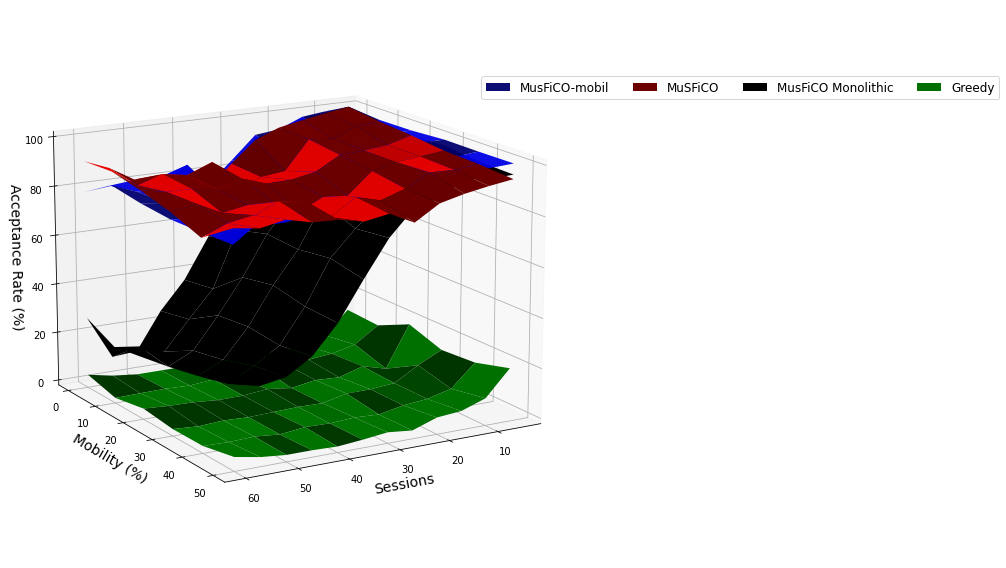

In [412]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(20, 8))

plt.rcParams["axes.labelsize"] = 13

c0 = ax.plot_surface(FLOWS, PROB, ar_1 * 100, color="blue", label="MusFiCO-mobil", alpha=0.95)
c1 = ax.plot_surface(FLOWS, PROB, ar_2 * 100, color="red", label="MuSFiCO")
c2 = ax.plot_surface(FLOWS, PROB, ar_3 * 100, color="black", label="MusFiCO Monolithic")
c3 = ax.plot_surface(FLOWS, PROB, ar_4 * 100, color="green", label="Greedy")

ax.set_xlabel("Sessions")
ax.set_ylabel("Mobility (%)")
ax.set_zlabel("Acceptance Rate (%)")
ax.set_yticks(prob, np.arange(60, step=10))
# ax.set_xticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
ax.view_init(15, 60)
c0._facecolors2d = c0._facecolor3d
c0._edgecolors2d = c0._edgecolor3d
c1._facecolors2d = c1._facecolor3d
c1._edgecolors2d = c1._edgecolor3d
c2._facecolors2d = c2._facecolor3d
c2._edgecolors2d = c2._edgecolor3d
c3._facecolors2d = c3._facecolor3d
c3._edgecolors2d = c3._edgecolor3d
fig.tight_layout()
# fig.legend(bbox_to_anchor=(0.83, 0.88), fontsize=10)
fig.legend(bbox_to_anchor=(0.78, 0.87), fontsize=12, ncol=4)
fig.savefig("figures/plot_3d_ar.png")

/tmp/ipykernel_10324/3200121991.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels([0, 20, 40, 60, 80, 100])
/tmp/ipykernel_10324/3200121991.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


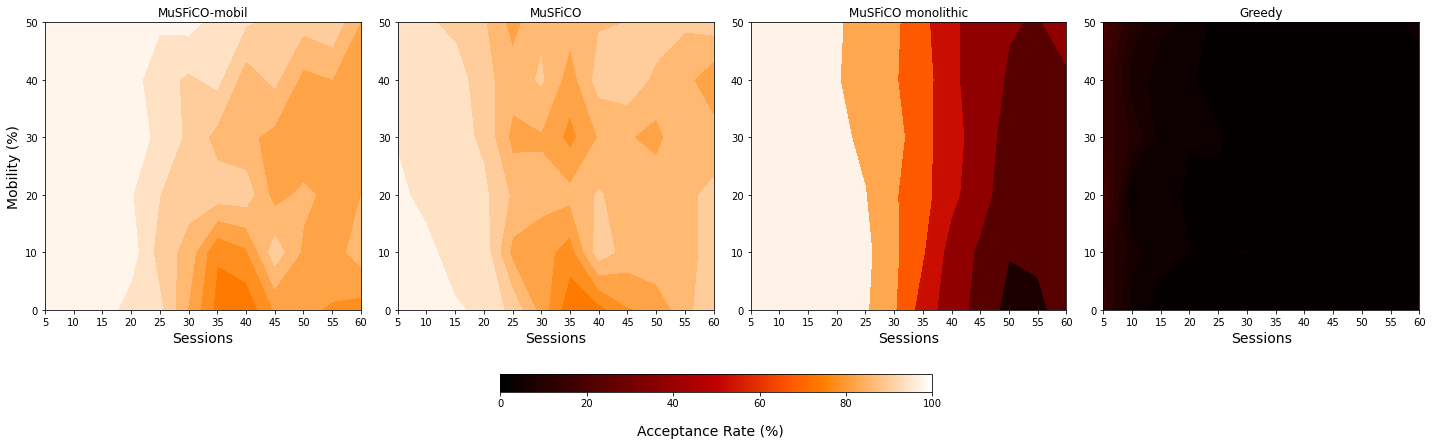

In [413]:
import seaborn as sns
import matplotlib as mpl

plt.rcParams["axes.labelsize"] = 14

cmap = sns.color_palette("gist_heat", as_cmap=True)

vmin = 0
vmax = 100

fig, ax = plt.subplots(ncols=4, figsize=(20, 5))
ax[0].contourf(FLOWS, PROB * 100, ar_1 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[0].set_ylabel("Mobility (%)")
ax[0].set_xlabel("Sessions")
ax[0].set_title("MuSFiCO-mobil")
ax[0].set_xticks(flows)
# ax[0].set_yticks([0, 10, 20, 30, 40, 50], [0, 10, 20, 30, 40, 50])

ax[1].contourf(FLOWS, PROB * 100, ar_2 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[1].set_xlabel("Sessions")
ax[1].set_title("MuSFiCO")
ax[1].set_xticks(flows)
# ax[1].set_yticks([0, 10, 20, 30, 40, 50], [0, 10, 20, 30, 40, 50])

ax[2].contourf(FLOWS, PROB * 100, ar_3 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[2].set_xlabel("Sessions")
ax[2].set_title("MuSFiCO monolithic")
ax[2].set_xticks(flows)
# ax[2].set_yticks([0, 10, 20, 30, 40, 50], [0, 10, 20, 30, 40, 50])


ax[3].contourf(FLOWS, PROB * 100, ar_4 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[3].set_xlabel("Sessions")
ax[3].set_title("Greedy")
ax[3].set_xticks(flows)
# ax[3].set_yticks([0, 10, 20, 30, 40, 50], [0, 10, 20, 30, 40, 50])
"""
ax[4].contourf(FLOWS, PROB * 100, ar_5 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[4].set_ylabel('Mobility (%)')
ax[4].set_xlabel('Sessions')
ax[4].set_title('BC SFC OFF')

ax[5].contourf(FLOWS, PROB * 100, ar_6 * 100, cmap=cmap, vmin=vmin, vmax=vmax)
ax[5].set_ylabel('Mobility (%)')
ax[5].set_xlabel('Sessions')
ax[5].set_title('Greedy SFC OFF')
"""
# position for the colorbar
fig.subplots_adjust()
# = fig.add_axes([0.35, -0.1 ,0.3 ,0.05])
# fig.colorbar(heat, orientation='horizontal', cax=cbar_ax)
cbar_ax = fig.add_axes([0.35, -0.1, 0.3, 0.05])
# cbar_ax.axes.get_xaxis().set_visible(False)
# cbar_ax.axes.get_yaxis().set_visible(False)
ax_3 = fig.text(x=0.445, y=-0.22, s="Acceptance Rate (%)", fontsize=14)
# ax_1 = fig.text(x=0.344, y=-0.14, s='0', fontsize=14)
# ax_2 = fig.text(x=0.64, y=-0.14, s='100', fontsize=14)
cbar = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, orientation="horizontal")
cbar.set_ticklabels([0, 20, 40, 60, 80, 100])
fig.tight_layout()
fig.savefig(
    "figures/heatmap.png",
    bbox_extra_artists=(
        cbar_ax,
        ax_3,
    ),
    bbox_inches="tight",
)
# TODO ADD LEGEND, ADD SCALE [0,1] TO COLORBAR

In [414]:
parameter = "latency"

In [415]:
parameter_beautify_name = {
    "cache_utilization": "Cache (%)",
    "duration": "Decision time (s)",
    "latency": "Latency (ms)",
    "bandwidth_utilization": "Bandwidth (%)",
    "cpu_utilization": "CPU (%)",
}
parameter_name = parameter_beautify_name[parameter]

if parameter == "latency" or parameter == "duration":
    PERCENTAGE = 1
    df_resource_filtered = df.copy()
    group_mean = dict(
        df_resource_filtered[df_resource_filtered["latency"] != -1]
        .groupby(["algorithm", "sfc", "prob"])["latency"]
        .mean()
    )

    for group in group_mean.keys():
        idx_list = df_resource_filtered[
            (df_resource_filtered["latency"] == -1)
            & (df_resource_filtered["algorithm"] == group[0])
            & (df_resource_filtered["sfc"] == group[1])
            & (df_resource_filtered["prob"] == group[2])
        ].index
        df_resource_filtered.loc[idx_list, "latency"] = group_mean[group]
else:
    PERCENTAGE = 100
    df_resource_filtered = df.copy()

In [416]:
df_resource_filtered = df_resource_filtered[
    df_resource_filtered.groupby(["sfc", "algorithm", "prob", "n_execution"])["sfc_id"]
    .transform(count_unique)
    .isin([NUMBER_OF_FLOWS * 4, NUMBER_OF_FLOWS * 8])
]

In [417]:
probs = ["0.0", "0.1", "0.2"]
# df_resource_filtered[df_resource_filtered['prob'].isin(probs)].groupby(['sfc', 'algorithm', 'prob', 'n_execution'])['timestamp'].apply(scaler.fit_transform)

In [418]:
data_plot_resource = {}
for group in df_resource_filtered.groupby(["sfc", "algorithm", "prob", "n_execution"]):
    key_dict = group[0][:-1]
    if key_dict not in data_plot_resource.keys():
        data_plot_resource[key_dict] = []
    time_array = scaler.fit_transform(group[1]["timestamp"].values.reshape(-1, 1))
    data_plot_resource[key_dict].append(
        resource_utilization(group[1][parameter].values, time_array)
    )

In [419]:
arr_dp_on_0_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "dp", "0.0")]))
)
arr_dp_on_10_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "dp", "0.1")]))
)
arr_dp_on_20_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "dp", "0.2")]))
)
arr_dp_on_30_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "dp", "0.3")]))
)
arr_dp_on_40_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "dp", "0.4")]))
)
arr_dp_on_50_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "dp", "0.5")]))
)
"""
arr_dp_on_60_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'dp', '0.6')])))
arr_dp_on_70_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'dp', '0.7')])))
arr_dp_on_80_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'dp', '0.8')])))
arr_dp_on_90_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'dp', '0.9')])))
arr_dp_on_100_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'dp', '1.0')])))
"""

arr_dpnew_on_0_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "musfico", "0.0")]))
)
arr_dpnew_on_10_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "musfico", "0.1")]))
)
arr_dpnew_on_20_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "musfico", "0.2")]))
)
arr_dpnew_on_30_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "musfico", "0.3")]))
)
arr_dpnew_on_40_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "musfico", "0.4")]))
)
arr_dpnew_on_50_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "musfico", "0.5")]))
)
"""
arr_dpnew_on_60_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'musfico', '0.6')])))
arr_dpnew_on_70_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'musfico', '0.7')])))
arr_dpnew_on_80_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'musfico', '0.8')])))
arr_dpnew_on_90_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'musfico', '0.9')])))
arr_dpnew_on_100_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'musfico', '1.0')])))
"""
arr_dpnew_off_0_resource = np.array(
    list(
        filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("off", "musfico", "0.0")])
    )
)
arr_dpnew_off_10_resource = np.array(
    list(
        filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("off", "musfico", "0.1")])
    )
)
arr_dpnew_off_20_resource = np.array(
    list(
        filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("off", "musfico", "0.2")])
    )
)
arr_dpnew_off_30_resource = np.array(
    list(
        filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("off", "musfico", "0.3")])
    )
)
arr_dpnew_off_40_resource = np.array(
    list(
        filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("off", "musfico", "0.4")])
    )
)
arr_dpnew_off_50_resource = np.array(
    list(
        filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("off", "musfico", "0.5")])
    )
)
"""
arr_dpnew_off_60_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('off', 'musfico', '0.6')])))
arr_dpnew_off_70_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('off', 'musfico', '0.7')])))
arr_dpnew_off_80_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('off', 'musfico', '0.8')])))
arr_dpnew_off_90_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('off', 'musfico', '0.9')])))
arr_dpnew_off_100_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('off', 'musfico', '1.0')])))
"""

arr_g_on_0_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "g", "0.0")]))
)
arr_g_on_10_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "g", "0.1")]))
)
arr_g_on_20_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "g", "0.2")]))
)
arr_g_on_30_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "g", "0.3")]))
)
arr_g_on_40_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "g", "0.4")]))
)
arr_g_on_50_resource = np.array(
    list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[("on", "g", "0.5")]))
)
"""
arr_g_on_60_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '0.6')])))
arr_g_on_70_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '0.7')])))
arr_g_on_80_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '0.8')])))
arr_g_on_90_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '0.9')])))
arr_g_on_100_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '1.0')])))
"""

"\narr_g_on_60_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '0.6')])))\narr_g_on_70_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '0.7')])))\narr_g_on_80_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '0.8')])))\narr_g_on_90_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '0.9')])))\narr_g_on_100_resource = np.array(list(filter(lambda x: len(x) == INTERVAL_LENGTH, data_plot_resource[('on', 'g', '1.0')])))\n"

In [420]:
arr_dp_on_0_resource = np.vstack(arr_dp_on_0_resource)
arr_dp_on_10_resource = np.vstack(arr_dp_on_10_resource)
arr_dp_on_20_resource = np.vstack(arr_dp_on_20_resource)
arr_dp_on_30_resource = np.vstack(arr_dp_on_30_resource)
arr_dp_on_40_resource = np.vstack(arr_dp_on_40_resource)
arr_dp_on_50_resource = np.vstack(arr_dp_on_50_resource)
"""
arr_dp_on_60_resource = np.vstack(arr_dp_on_60_resource)
arr_dp_on_70_resource = np.vstack(arr_dp_on_70_resource)
arr_dp_on_80_resource = np.vstack(arr_dp_on_80_resource)
arr_dp_on_90_resource = np.vstack(arr_dp_on_90_resource)
arr_dp_on_100_resource = np.vstack(arr_dp_on_100_resource)
"""

arr_dpnew_on_0_resource = np.vstack(arr_dpnew_on_0_resource)
arr_dpnew_on_10_resource = np.vstack(arr_dpnew_on_10_resource)
arr_dpnew_on_20_resource = np.vstack(arr_dpnew_on_20_resource)
arr_dpnew_on_30_resource = np.vstack(arr_dpnew_on_30_resource)
arr_dpnew_on_40_resource = np.vstack(arr_dpnew_on_40_resource)
arr_dpnew_on_50_resource = np.vstack(arr_dpnew_on_50_resource)

"""
arr_dpnew_on_60_resource = np.vstack(arr_dpnew_on_60_resource)
arr_dpnew_on_70_resource = np.vstack(arr_dpnew_on_70_resource)
arr_dpnew_on_80_resource = np.vstack(arr_dpnew_on_80_resource)
arr_dpnew_on_90_resource = np.vstack(arr_dpnew_on_90_resource)
arr_dpnew_on_100_resource = np.vstack(arr_dpnew_on_100_resource)
"""

arr_dpnew_off_0_resource = np.vstack(arr_dpnew_off_0_resource)
arr_dpnew_off_10_resource = np.vstack(arr_dpnew_off_10_resource)
arr_dpnew_off_20_resource = np.vstack(arr_dpnew_off_20_resource)
arr_dpnew_off_30_resource = np.vstack(arr_dpnew_off_30_resource)
arr_dpnew_off_40_resource = np.vstack(arr_dpnew_off_40_resource)
arr_dpnew_off_50_resource = np.vstack(arr_dpnew_off_50_resource)

"""
arr_dpnew_off_60_resource = np.vstack(arr_dpnew_off_60_resource)
arr_dpnew_off_70_resource = np.vstack(arr_dpnew_off_70_resource)
arr_dpnew_off_80_resource = np.vstack(arr_dpnew_off_80_resource)
arr_dpnew_off_90_resource = np.vstack(arr_dpnew_off_90_resource)
arr_dpnew_off_100_resource = np.vstack(arr_dpnew_off_100_resource)
"""

arr_g_on_0_resource = np.vstack(arr_g_on_0_resource)
arr_g_on_10_resource = np.vstack(arr_g_on_10_resource)
arr_g_on_20_resource = np.vstack(arr_g_on_20_resource)
arr_g_on_30_resource = np.vstack(arr_g_on_30_resource)
arr_g_on_40_resource = np.vstack(arr_g_on_40_resource)
arr_g_on_50_resource = np.vstack(arr_g_on_50_resource)

"""
arr_g_on_60_resource = np.vstack(arr_g_on_60_resource)
arr_g_on_70_resource = np.vstack(arr_g_on_70_resource)
arr_g_on_80_resource = np.vstack(arr_g_on_80_resource)
arr_g_on_90_resource = np.vstack(arr_g_on_90_resource)
arr_g_on_100_resource = np.vstack(arr_g_on_100_resource)
"""

'\narr_g_on_60_resource = np.vstack(arr_g_on_60_resource)\narr_g_on_70_resource = np.vstack(arr_g_on_70_resource)\narr_g_on_80_resource = np.vstack(arr_g_on_80_resource)\narr_g_on_90_resource = np.vstack(arr_g_on_90_resource)\narr_g_on_100_resource = np.vstack(arr_g_on_100_resource)\n'

In [421]:
mean_arr_dp_on_0_resource = np.mean(arr_dp_on_0_resource, axis=0)
mean_arr_dp_on_10_resource = np.mean(arr_dp_on_10_resource, axis=0)
mean_arr_dp_on_20_resource = np.mean(arr_dp_on_20_resource, axis=0)
mean_arr_dp_on_30_resource = np.mean(arr_dp_on_30_resource, axis=0)
mean_arr_dp_on_40_resource = np.mean(arr_dp_on_40_resource, axis=0)
mean_arr_dp_on_50_resource = np.mean(arr_dp_on_50_resource, axis=0)

"""
mean_arr_dp_on_60_resource = np.mean(arr_dp_on_60_resource, axis=0)
mean_arr_dp_on_70_resource = np.mean(arr_dp_on_70_resource, axis=0)
mean_arr_dp_on_80_resource = np.mean(arr_dp_on_80_resource, axis=0)
mean_arr_dp_on_90_resource = np.mean(arr_dp_on_90_resource, axis=0)
mean_arr_dp_on_100_resource = np.mean(arr_dp_on_100_resource, axis=0)
"""

mean_arr_dpnew_on_0_resource = np.mean(arr_dpnew_on_0_resource, axis=0)
mean_arr_dpnew_on_10_resource = np.mean(arr_dpnew_on_10_resource, axis=0)
mean_arr_dpnew_on_20_resource = np.mean(arr_dpnew_on_20_resource, axis=0)
mean_arr_dpnew_on_30_resource = np.mean(arr_dpnew_on_30_resource, axis=0)
mean_arr_dpnew_on_40_resource = np.mean(arr_dpnew_on_40_resource, axis=0)
mean_arr_dpnew_on_50_resource = np.mean(arr_dpnew_on_50_resource, axis=0)

"""
mean_arr_dpnew_on_60_resource = np.mean(arr_dpnew_on_60_resource, axis=0)
mean_arr_dpnew_on_70_resource = np.mean(arr_dpnew_on_70_resource, axis=0)
mean_arr_dpnew_on_80_resource = np.mean(arr_dpnew_on_80_resource, axis=0)
mean_arr_dpnew_on_90_resource = np.mean(arr_dpnew_on_90_resource, axis=0)
mean_arr_dpnew_on_100_resource = np.mean(arr_dpnew_on_100_resource, axis=0)
"""

mean_arr_dpnew_off_0_resource = np.mean(arr_dpnew_off_0_resource, axis=0)
mean_arr_dpnew_off_10_resource = np.mean(arr_dpnew_off_10_resource, axis=0)
mean_arr_dpnew_off_20_resource = np.mean(arr_dpnew_off_20_resource, axis=0)
mean_arr_dpnew_off_30_resource = np.mean(arr_dpnew_off_30_resource, axis=0)
mean_arr_dpnew_off_40_resource = np.mean(arr_dpnew_off_40_resource, axis=0)
mean_arr_dpnew_off_50_resource = np.mean(arr_dpnew_off_50_resource, axis=0)

"""
mean_arr_dpnew_off_60_resource = np.mean(arr_dpnew_off_60_resource, axis=0)
mean_arr_dpnew_off_70_resource = np.mean(arr_dpnew_off_70_resource, axis=0)
mean_arr_dpnew_off_80_resource = np.mean(arr_dpnew_off_80_resource, axis=0)
mean_arr_dpnew_off_90_resource = np.mean(arr_dpnew_off_90_resource, axis=0)
mean_arr_dpnew_off_100_resource = np.mean(arr_dpnew_off_100_resource, axis=0)
"""

mean_arr_g_on_0_resource = np.mean(arr_g_on_0_resource, axis=0)
mean_arr_g_on_10_resource = np.mean(arr_g_on_10_resource, axis=0)
mean_arr_g_on_20_resource = np.mean(arr_g_on_20_resource, axis=0)
mean_arr_g_on_30_resource = np.mean(arr_g_on_30_resource, axis=0)
mean_arr_g_on_40_resource = np.mean(arr_g_on_40_resource, axis=0)
mean_arr_g_on_50_resource = np.mean(arr_g_on_50_resource, axis=0)

"""
mean_arr_g_on_60_resource = np.mean(arr_g_on_60_resource, axis=0)
mean_arr_g_on_70_resource = np.mean(arr_g_on_70_resource, axis=0)
mean_arr_g_on_80_resource = np.mean(arr_g_on_80_resource, axis=0)
mean_arr_g_on_90_resource = np.mean(arr_g_on_90_resource, axis=0)
mean_arr_g_on_100_resource = np.mean(arr_g_on_100_resource, axis=0)
"""

'\nmean_arr_g_on_60_resource = np.mean(arr_g_on_60_resource, axis=0)\nmean_arr_g_on_70_resource = np.mean(arr_g_on_70_resource, axis=0)\nmean_arr_g_on_80_resource = np.mean(arr_g_on_80_resource, axis=0)\nmean_arr_g_on_90_resource = np.mean(arr_g_on_90_resource, axis=0)\nmean_arr_g_on_100_resource = np.mean(arr_g_on_100_resource, axis=0)\n'

In [422]:
from scipy.stats import sem

sem_arr_dp_on_0_resource = sem(arr_dp_on_0_resource, axis=0)
sem_arr_dp_on_10_resource = sem(arr_dp_on_10_resource, axis=0)
sem_arr_dp_on_20_resource = sem(arr_dp_on_20_resource, axis=0)
sem_arr_dp_on_30_resource = sem(arr_dp_on_30_resource, axis=0)
sem_arr_dp_on_40_resource = sem(arr_dp_on_40_resource, axis=0)
sem_arr_dp_on_50_resource = sem(arr_dp_on_50_resource, axis=0)

"""
sem_arr_dp_on_60_resource =sem(arr_dp_on_60_resource, axis=0)
sem_arr_dp_on_70_resource =sem(arr_dp_on_70_resource, axis=0)
sem_arr_dp_on_80_resource =sem(arr_dp_on_80_resource, axis=0)
sem_arr_dp_on_90_resource =sem(arr_dp_on_90_resource, axis=0)
sem_arr_dp_on_100_resource =sem(arr_dp_on_100_resource, axis=0)
"""

sem_arr_dpnew_on_0_resource = sem(arr_dpnew_on_0_resource, axis=0)
sem_arr_dpnew_on_10_resource = sem(arr_dpnew_on_10_resource, axis=0)
sem_arr_dpnew_on_20_resource = sem(arr_dpnew_on_20_resource, axis=0)
sem_arr_dpnew_on_30_resource = sem(arr_dpnew_on_30_resource, axis=0)
sem_arr_dpnew_on_40_resource = sem(arr_dpnew_on_40_resource, axis=0)
sem_arr_dpnew_on_50_resource = sem(arr_dpnew_on_50_resource, axis=0)

"""
sem_arr_dpnew_on_60_resource =sem(arr_dpnew_on_60_resource, axis=0)
sem_arr_dpnew_on_70_resource =sem(arr_dpnew_on_70_resource, axis=0)
sem_arr_dpnew_on_80_resource =sem(arr_dpnew_on_80_resource, axis=0)
sem_arr_dpnew_on_90_resource =sem(arr_dpnew_on_90_resource, axis=0)
sem_arr_dpnew_on_100_resource =sem(arr_dpnew_on_100_resource, axis=0)
"""

sem_arr_dpnew_off_0_resource = sem(arr_dpnew_off_0_resource, axis=0)
sem_arr_dpnew_off_10_resource = sem(arr_dpnew_off_10_resource, axis=0)
sem_arr_dpnew_off_20_resource = sem(arr_dpnew_off_20_resource, axis=0)
sem_arr_dpnew_off_30_resource = sem(arr_dpnew_off_30_resource, axis=0)
sem_arr_dpnew_off_40_resource = sem(arr_dpnew_off_40_resource, axis=0)
sem_arr_dpnew_off_50_resource = sem(arr_dpnew_off_50_resource, axis=0)

"""
sem_arr_dpnew_off_60_resource =sem(arr_dpnew_off_60_resource, axis=0)
sem_arr_dpnew_off_70_resource =sem(arr_dpnew_off_70_resource, axis=0)
sem_arr_dpnew_off_80_resource =sem(arr_dpnew_off_80_resource, axis=0)
sem_arr_dpnew_off_90_resource =sem(arr_dpnew_off_90_resource, axis=0)
sem_arr_dpnew_off_100_resource =sem(arr_dpnew_off_100_resource, axis=0)
"""

sem_arr_g_on_0_resource = sem(arr_g_on_0_resource, axis=0)
sem_arr_g_on_10_resource = sem(arr_g_on_10_resource, axis=0)
sem_arr_g_on_20_resource = sem(arr_g_on_20_resource, axis=0)
sem_arr_g_on_30_resource = sem(arr_g_on_30_resource, axis=0)
sem_arr_g_on_40_resource = sem(arr_g_on_40_resource, axis=0)
sem_arr_g_on_50_resource = sem(arr_g_on_50_resource, axis=0)
"""
sem_arr_g_on_60_resource =sem(arr_g_on_60_resource, axis=0)
sem_arr_g_on_70_resource =sem(arr_g_on_70_resource, axis=0)
sem_arr_g_on_80_resource =sem(arr_g_on_80_resource, axis=0)
sem_arr_g_on_90_resource =sem(arr_g_on_90_resource, axis=0)
sem_arr_g_on_100_resource =sem(arr_g_on_100_resource, axis=0)
"""

'\nsem_arr_g_on_60_resource =sem(arr_g_on_60_resource, axis=0)\nsem_arr_g_on_70_resource =sem(arr_g_on_70_resource, axis=0)\nsem_arr_g_on_80_resource =sem(arr_g_on_80_resource, axis=0)\nsem_arr_g_on_90_resource =sem(arr_g_on_90_resource, axis=0)\nsem_arr_g_on_100_resource =sem(arr_g_on_100_resource, axis=0)\n'

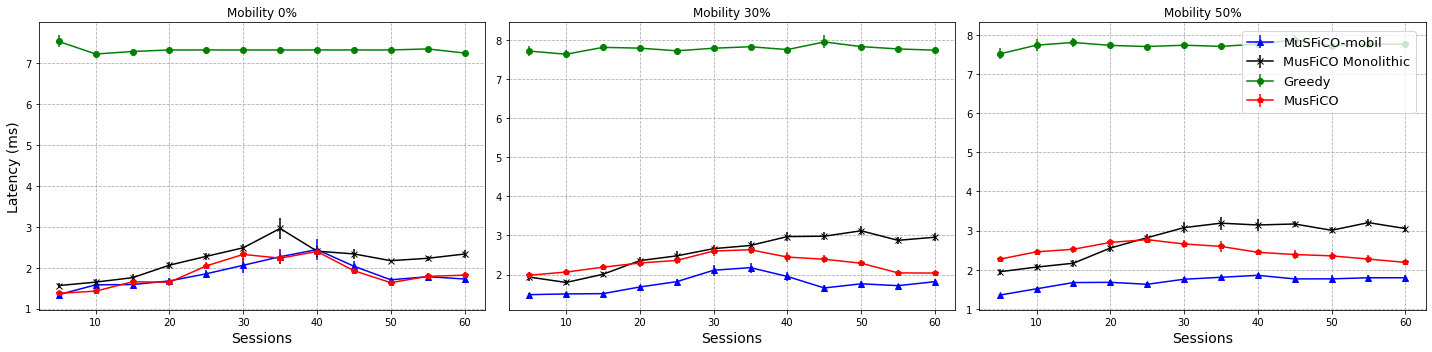

In [423]:
fig, axs = plt.subplots(ncols=3, figsize=(20, 5))

axs[0].errorbar(
    flows,
    mean_arr_dp_on_0_resource * PERCENTAGE,
    yerr=sem_arr_dp_on_0_resource,
    c="blue",
    marker="^",
    label="MuSFiCO-mobil",
)
axs[0].errorbar(
    flows,
    mean_arr_dpnew_off_0_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_off_0_resource,
    c="black",
    marker="x",
    label="MusFiCO Monolithic",
)
axs[0].errorbar(
    flows,
    mean_arr_g_on_0_resource * PERCENTAGE,
    yerr=sem_arr_g_on_0_resource,
    c="green",
    marker="o",
    label="Greedy",
)
axs[0].errorbar(
    flows,
    mean_arr_dpnew_on_0_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_on_0_resource,
    c="red",
    marker="p",
    label="MusFiCO",
)
axs[0].set_title("Mobility 0%")
axs[0].set_xlabel("Sessions")
axs[0].set_ylabel(f"{parameter_name}")
# axs[0].set_ylim([0, 10])
axs[0].grid(True, axis="both", linestyle="dashed")

axs[1].errorbar(
    flows,
    mean_arr_dp_on_30_resource * PERCENTAGE,
    yerr=sem_arr_dp_on_30_resource,
    c="blue",
    marker="^",
)
axs[1].errorbar(
    flows,
    mean_arr_dpnew_off_30_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_off_30_resource,
    c="black",
    marker="x",
)
axs[1].errorbar(
    flows,
    mean_arr_g_on_30_resource * PERCENTAGE,
    yerr=sem_arr_g_on_30_resource,
    c="green",
    marker="o",
)
axs[1].errorbar(
    flows,
    mean_arr_dpnew_on_30_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_on_30_resource,
    c="red",
    marker="p",
)
axs[1].set_title("Mobility 30%")
# axs[1].set_ylim([0, 10])
axs[1].set_xlabel("Sessions")
axs[1].grid(True, axis="both", linestyle="dashed")

axs[2].errorbar(
    flows,
    mean_arr_dp_on_50_resource * PERCENTAGE,
    yerr=sem_arr_dp_on_50_resource,
    c="blue",
    marker="^",
)
axs[2].errorbar(
    flows,
    mean_arr_dpnew_off_50_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_off_50_resource,
    c="black",
    marker="x",
)
axs[2].errorbar(
    flows,
    mean_arr_g_on_50_resource * PERCENTAGE,
    yerr=sem_arr_g_on_50_resource,
    c="green",
    marker="o",
)
axs[2].errorbar(
    flows,
    mean_arr_dpnew_on_50_resource * PERCENTAGE,
    yerr=sem_arr_dpnew_on_50_resource,
    c="red",
    marker="p",
)
axs[2].set_title("Mobility 50%")
# axs[2].set_ylim([0, 10])
axs[2].set_xlabel("Sessions")
axs[2].grid(True, axis="both", linestyle="dashed")

ax_1 = fig.legend(bbox_to_anchor=(0.99, 0.92), fontsize=13)
fig.tight_layout()
fig.savefig(f"figures/{parameter}.png")